# 📌 Extracão

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_json("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json")
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
df_final = pd.json_normalize(df.to_dict(orient='records'), sep='_')
df_final.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 🔧 Transformação

In [3]:
cols_yes_or_no = [
  'Churn', 'customer_Partner', 'customer_Dependents',
  'phone_PhoneService', 'phone_MultipleLines', 'internet_OnlineBackup',
  'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV',
  'internet_StreamingMovies', 'account_PaperlessBilling', 'internet_OnlineSecurity'
  ]
df_final[cols_yes_or_no] = df_final[cols_yes_or_no].map(lambda cell: 'yes' in cell.lower())
df_final

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,False,Female,0,True,True,9,True,False,DSL,...,True,False,True,True,False,One year,True,Mailed check,65.60,593.3
1,0003-MKNFE,False,Male,0,False,False,9,True,True,DSL,...,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.4
2,0004-TLHLJ,True,Male,0,False,False,4,True,False,Fiber optic,...,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,1,True,False,13,True,False,Fiber optic,...,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,1,True,False,3,True,False,Fiber optic,...,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,0,False,False,13,True,False,DSL,...,False,False,True,False,False,One year,False,Mailed check,55.15,742.9
7263,9992-RRAMN,True,Male,0,True,False,22,True,True,Fiber optic,...,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.7
7264,9992-UJOEL,False,Male,0,False,False,2,True,False,DSL,...,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,0,True,True,67,True,False,DSL,...,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [4]:
df_final['customer_SeniorCitizen'] = df_final['customer_SeniorCitizen'].astype(np.bool)
df_final

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,True,False,True,True,False,One year,True,Mailed check,65.60,593.3
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.4
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,...,False,False,True,False,False,One year,False,Mailed check,55.15,742.9
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,...,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.7
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,...,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,...,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [5]:
df_final['account_Charges_Total'] = df_final['account_Charges_Total'].apply(lambda cell: np.nan if cell == ' ' else cell).astype(np.float64)
df_final

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,True,False,True,True,False,One year,True,Mailed check,65.60,593.30
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,...,False,False,True,False,False,One year,False,Mailed check,55.15,742.90
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,...,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,...,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,...,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [6]:
df_final = df_final.assign(Contas_Diarias=df_final['account_Charges_Monthly'] / 30)

In [7]:
df_churn = df_final[df_final['Churn'] == True]
df_not_churn = df_final[df_final['Churn'] == False]

In [8]:
df_not_churn.describe()

,customer_tenure,account_Charges_Monthly,account_Charges_Total,Contas_Diarias
count,5398.000000,5398.000000,5387.000000,5398.000000
mean,37.321045,61.354224,2540.440867,2.045141
std,24.178367,31.105006,2330.360507,1.036834
min,0.000000,18.250000,18.800000,0.608333
25%,14.000000,25.100000,568.000000,0.836667
50%,37.000000,64.500000,1669.400000,2.150000
75%,61.000000,88.637500,4247.825000,2.954583
max,72.000000,118.750000,8672.450000,3.958333


In [9]:
df_churn.describe()

,customer_tenure,account_Charges_Monthly,account_Charges_Total,Contas_Diarias
count,1869.000000,1869.000000,1869.000000,1869.000000
mean,17.979133,74.441332,1531.796094,2.481378
std,19.531123,24.666053,1890.822994,0.822202
min,1.000000,18.850000,18.850000,0.628333
25%,2.000000,56.150000,134.500000,1.871667
50%,10.000000,79.650000,703.550000,2.655000
75%,29.000000,94.200000,2331.300000,3.140000
max,72.000000,118.350000,8684.800000,3.945000


# 📊 Carga e análise

<Axes: title={'center': 'Contratos'}>

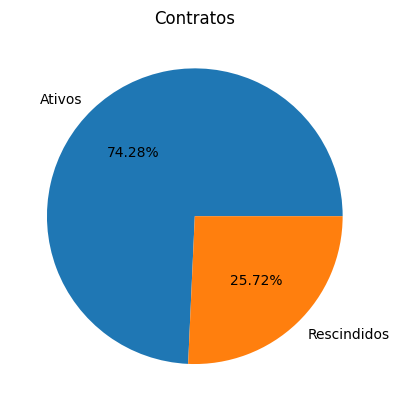

In [10]:
df_final['Churn'].value_counts().plot(kind='pie', title='Contratos', ylabel='', labels=['Ativos', 'Rescindidos'], autopct='%1.2f%%')

<Axes: title={'center': 'Distribuição por gênero dos contratos rescindidos'}>

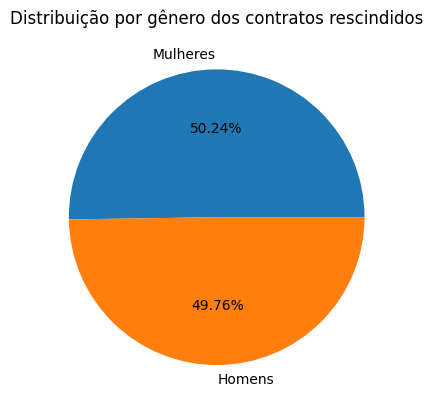

In [11]:
df_churn.groupby('customer_gender')['Churn'].value_counts().plot(kind='pie', ylabel='', title='Distribuição por gênero dos contratos rescindidos', autopct='%1.2f%%', labels=['Mulheres', 'Homens'])

<Axes: title={'center': 'Distribuição por gênero dos contratos ativos'}>

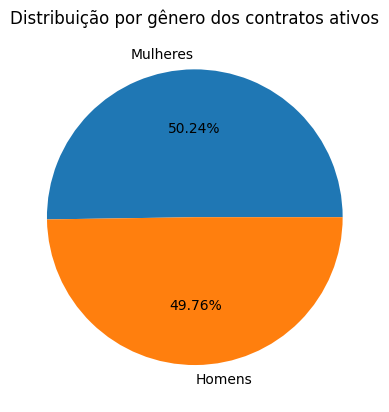

In [12]:
df_churn.groupby('customer_gender')['Churn'].value_counts().plot(kind='pie', ylabel='', title='Distribuição por gênero dos contratos ativos', autopct='%1.2f%%', labels=['Mulheres', 'Homens'])

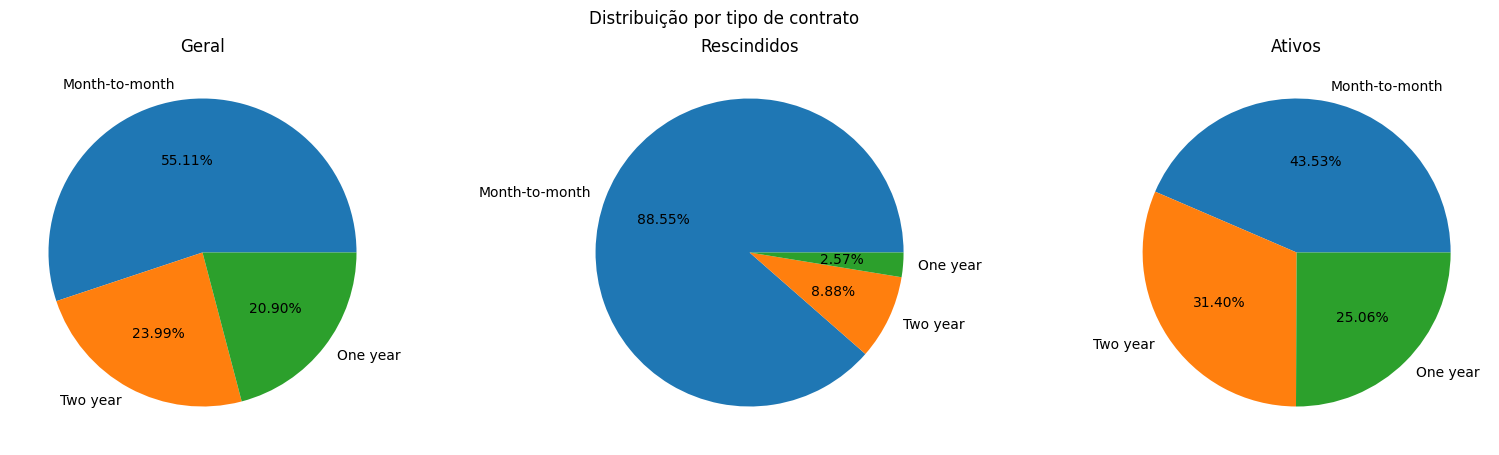

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

fig.suptitle('Distribuição por tipo de contrato')

def plot_bar(ds, **kwargs):
  ds.value_counts().plot(kind='barh', ylabel='', **kwargs)

def plot_pie_by_df_and_col(col, lbls, ax, **kwargs):
  arr_df = [df_final, df_churn, df_not_churn]
  titles = ['Geral', 'Rescindidos', 'Ativos']
  for i, df in enumerate(arr_df):
    if lbls is None:
      lbls = df_final[col].value_counts().index

    df[col].value_counts().plot(kind='pie', ylabel='', autopct='%1.2f%%', labels=lbls, ax=ax[i], title=titles[i], **kwargs)

# df_final['account_Contract'].value_counts().plot(ax=ax[0], kind='barh', title='Geral', ylabel='')
# plot_bar(df_final['account_Contract'], ax=ax[0])
# df_churn['account_Contract'].value_counts().plot(ax=ax[1], kind='barh', title='Rescindidos', ylabel='')
# df_not_churn['account_Contract'].value_counts().plot(ax=ax[2], kind='barh', title='Ativos', ylabel='')
# ax[1].set_yticks([])
# ax[2].set_yticks([])
plot_pie_by_df_and_col('account_Contract', None, ax)


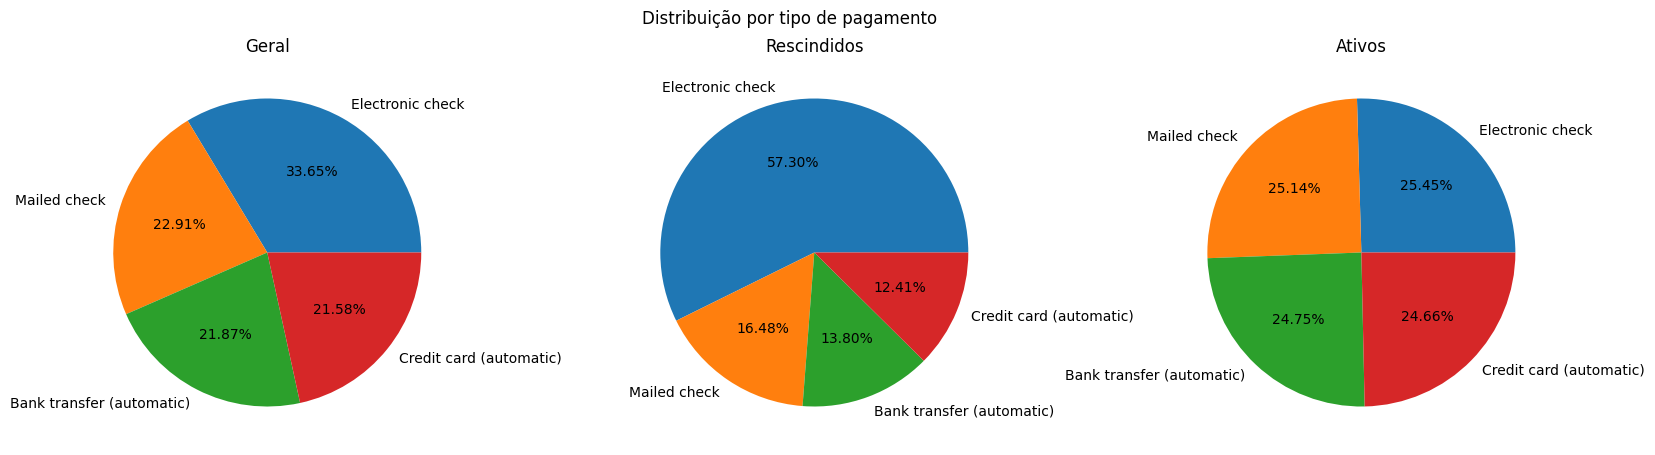

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

fig.suptitle('Distribuição por tipo de pagamento')

plot_pie_by_df_and_col('account_PaymentMethod', None, ax)


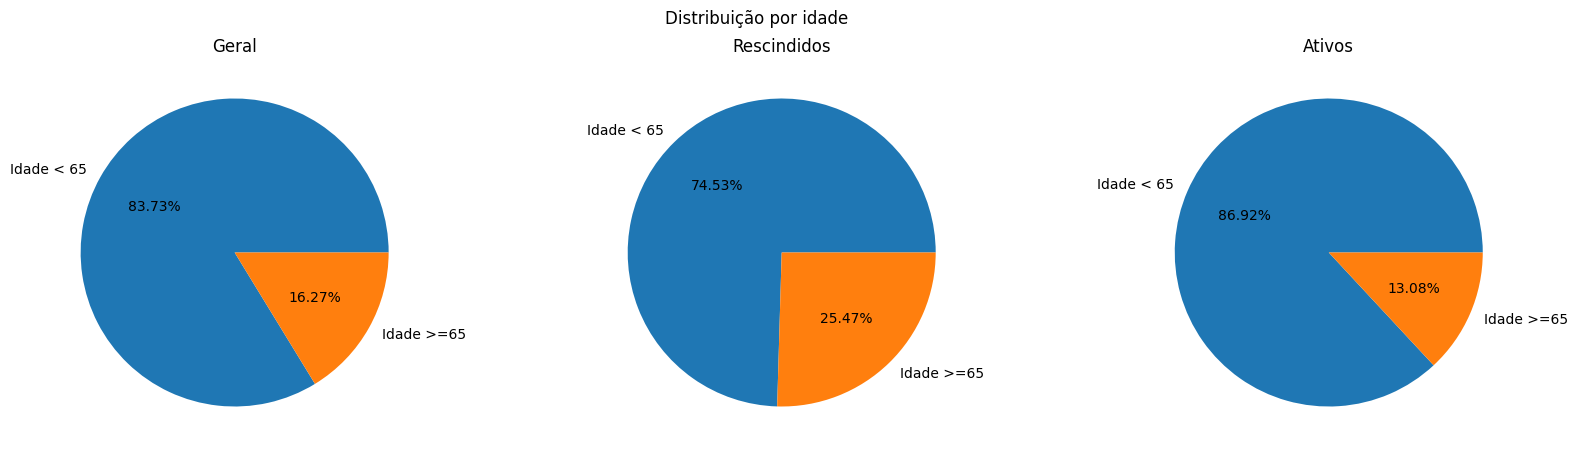

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

fig.suptitle('Distribuição por idade')

plot_pie_by_df_and_col('customer_SeniorCitizen', ['Idade < 65', 'Idade >=65'], ax)


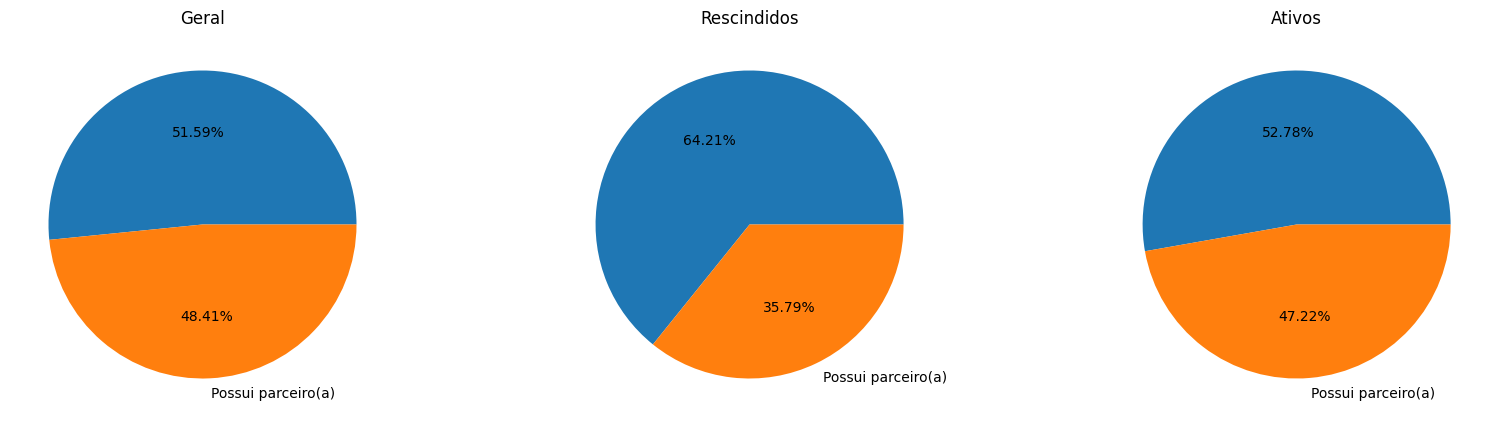

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

plot_pie_by_df_and_col('customer_Partner', ['', 'Possui parceiro(a)'], ax)

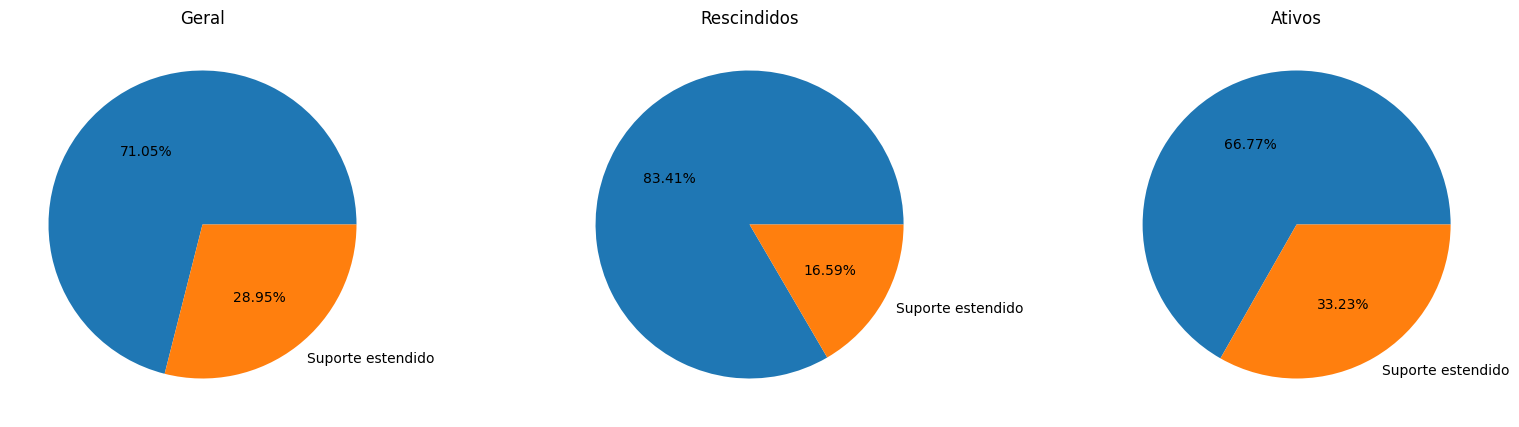

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

plot_pie_by_df_and_col('internet_TechSupport', ['', 'Suporte estendido'], ax)

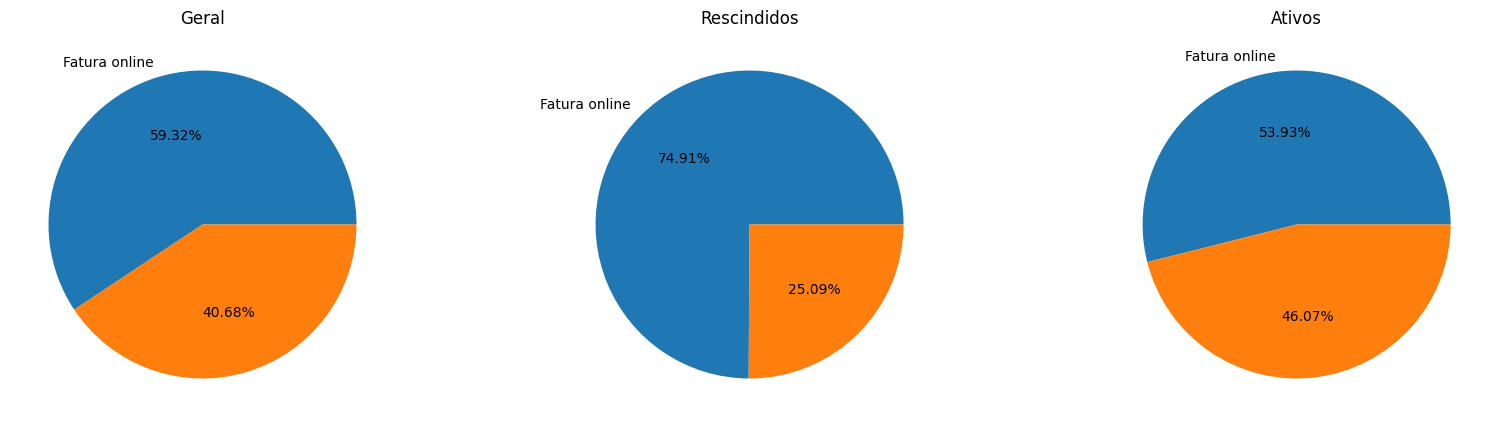

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

plot_pie_by_df_and_col('account_PaperlessBilling', ['Fatura online', ''], ax)

<Axes: title={'center': 'Ativos'}, xlabel='customer_tenure'>

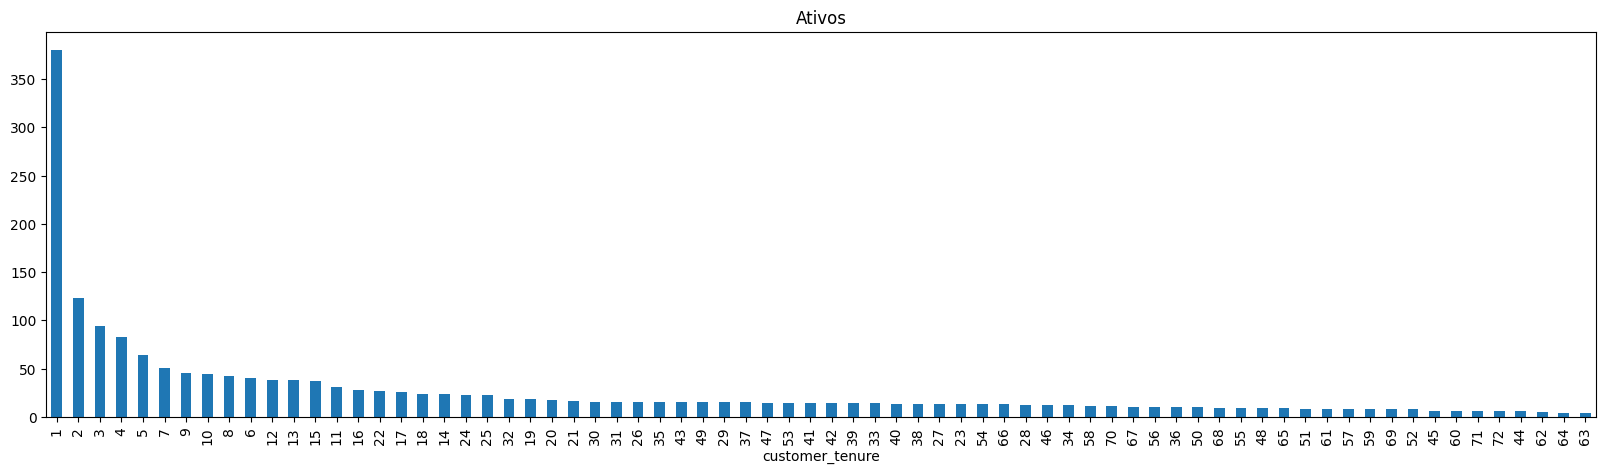

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))

df_churn['customer_tenure'].value_counts().plot(kind='bar', ylabel='', ax=ax, title=titles[i])

In [42]:
cols = ['Churn', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 
       'account_PaperlessBilling',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias']

df_final[cols].corr()['Churn']

,Churn
Churn,1.000000
customer_SeniorCitizen,0.146733
customer_Partner,-0.148546
customer_Dependents,-0.161384
customer_tenure,-0.344079
phone_PhoneService,0.012571
phone_MultipleLines,0.039343
internet_OnlineSecurity,-0.166828
internet_OnlineBackup,-0.080163
internet_DeviceProtection,-0.063452


# 📄Relatorio Final

## Introdução

A Telecom X está sofrendo com uma grande onda de rescisão de contratos de seus clientes. Diante desta situação, se faz necessário realizar uma análise dos dados contratuais desta empresa a fim de entender e levantar possíveis causas para esta onda.

## Tratamento
Os dados dos contratos estão expostos em uma API que retorna um json com dados sobre os contratos e informações básicas sobre o cliente relacionado ao respectivo contrato. Utilizamos o método `read_json` da biblioteca `Pandas` para importar este json da API. No entanto, existem alguns atributos que estão aninhados neste json. Para resolver este problema de aninhamento e acessarmos os dados, utilizamos os métodos `json_normalize` e `to_dict`.



## Análise
A análise exploratória dos dados, se inicia com uma breve formatação dos dados para tipos booleanos, float e inteiro. Com isso, realizamos alguns plots para compreender como esses dados se comportam e, de início, notasse que 88,55% dos contratos rescindidos possuem uma forma de pagamento **mensal**

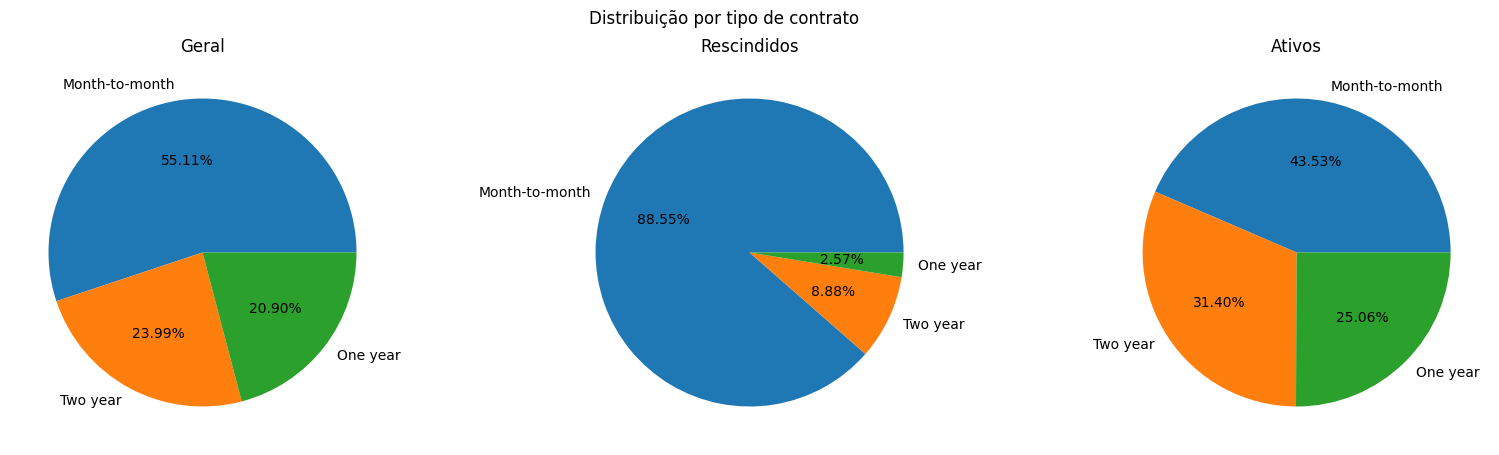

Ainda sobre os contratos rescindidos, quase 60% deles possuem, como forma de **pagamento** o Cheque eletrônico. Além disso, cerca de 3/4 dos clientes desses contratos optaram pelo recebimento da **fatura online**.

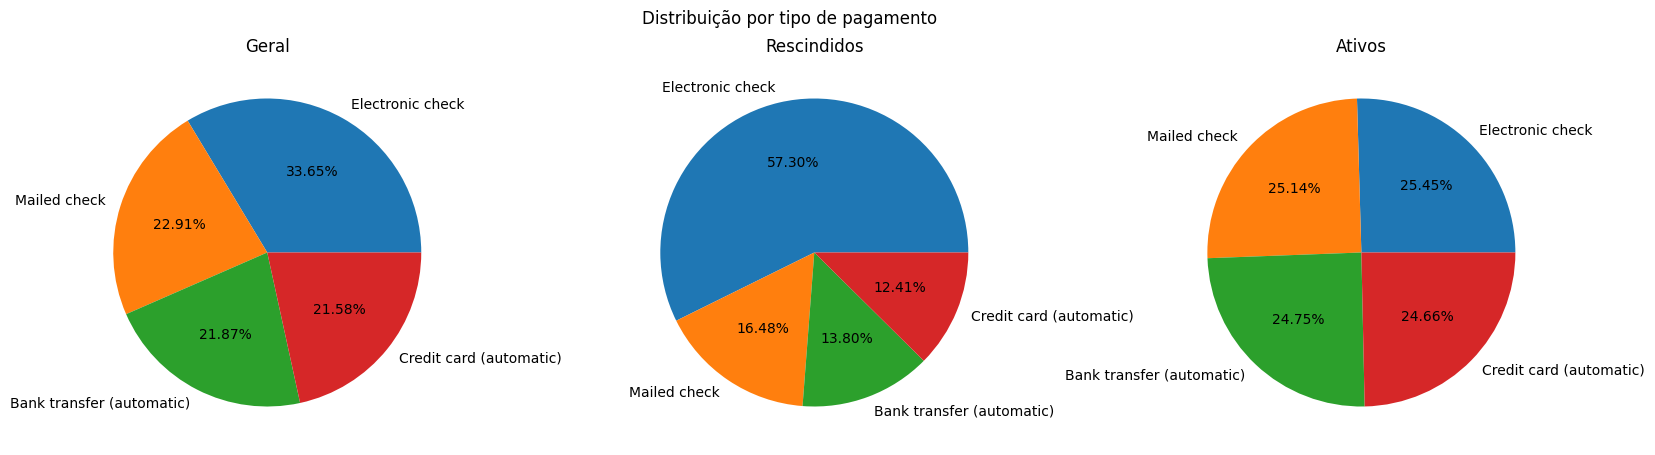

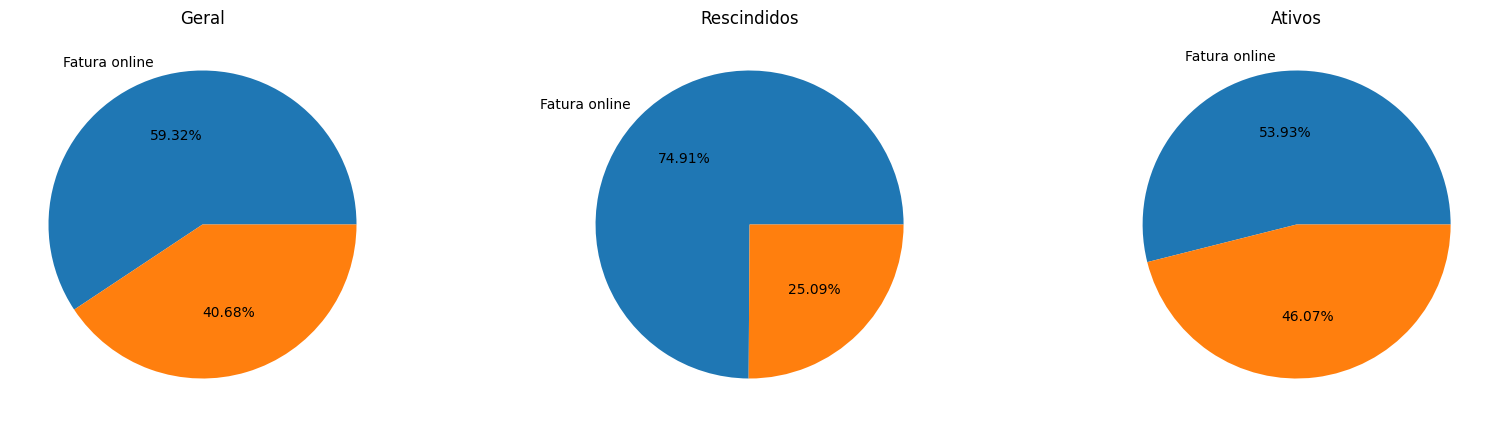

Para além dos contratos, os clientes parecem ter o seguinte perfil: pessoas com menos de 65 anos que não possuem parceiro(a) e que optaram por **não assinar** o suporte estendido, como mostram os gráficos a seguir.

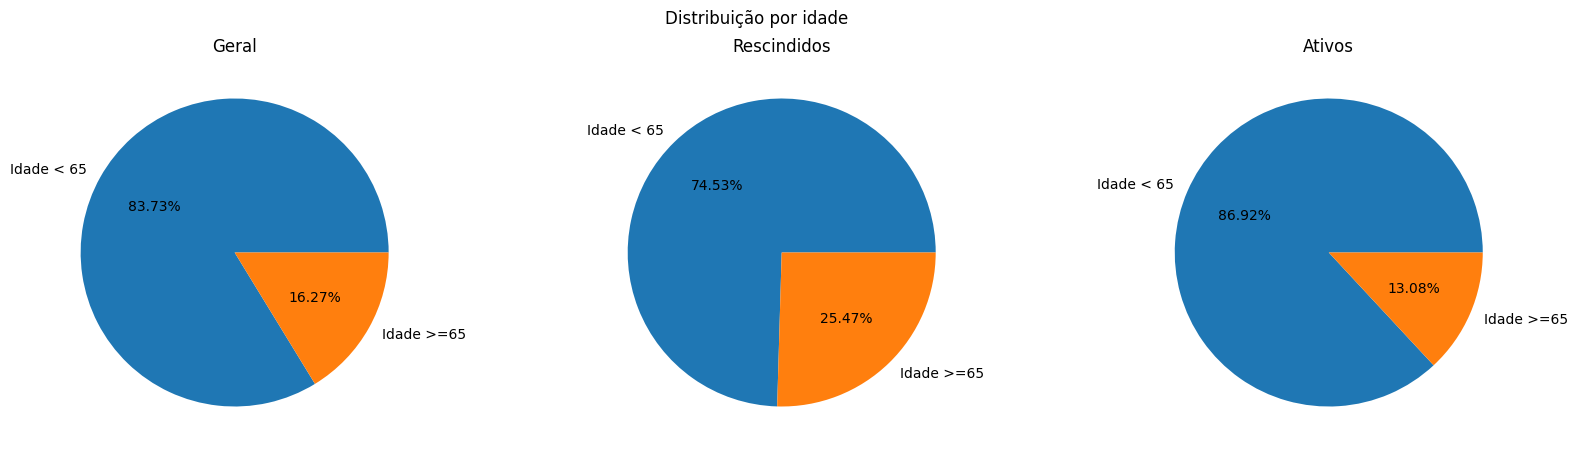

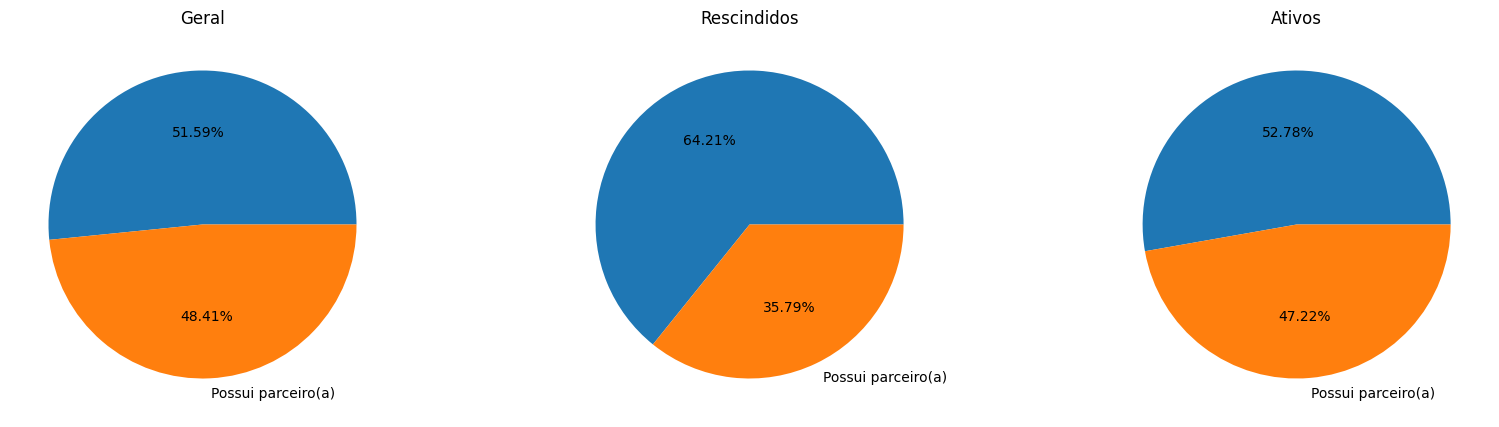

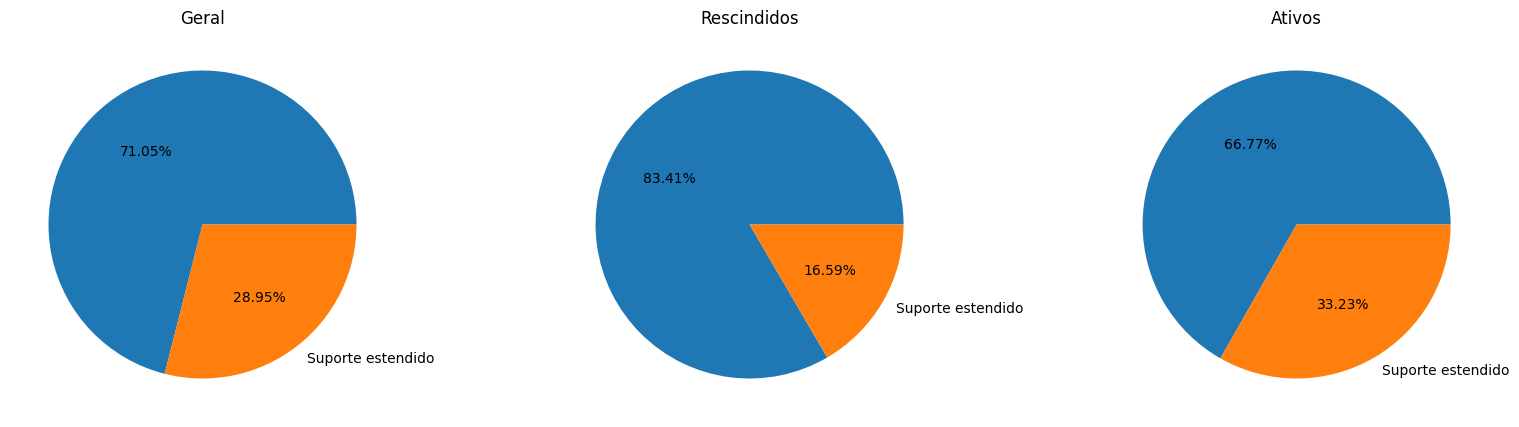

## Conclusão
Podemos concluir, por meio desta análise, que há indícios de perfis de clientes e contratos que possuem mais chances de evasão. Os dados mostram que clientes que **não contratam o suporte estendido**, optam pelo **pagamento mensal**, **fatura online** e possuem apenas **um mês de contrato** tendem a rescindir o contrato com a Telecom X.

## Recomendações

Com base nesta análise, sugerimos as seguintes ações:
* Promoções para que os clientes que possuem pagamento mensal migrem para o pagamento anual ou bienal;
* Campanha focada em pessoas com mais de 65 anos para que contratem o suporte estendido;
* Criação de um programa fidelidade, para que mais clientes passem do primeiro mês de contrato. 